### Importing Libararies

In [1]:
import pandas as pd
import numpy as np

### Reading the data 

In [2]:
df = pd.read_csv("claims.csv")

In [3]:
df.head()

,Tracking Number,Claim Date,Approval Date,Lease Street Address,Lease City,Lease State,Lease Zip,Lease Start Date,Lease End Date,Move-Out Date,...,Collected Amount,Collection Processed Date,Review Claim Adjudication,Review Tenant Information,Update YRIG Policy Info,Open Collections,View PM Information,PM Notification of Claim Received,Send to Collections,Audit Selection
0,1246,04/04/25,NaN,3121 LILY WAY,KENNESAW,GA,30144,03/22/24,03/31/25,03/14/25,...,NaN,NaN,No,Yes,Yes,No,No,True,NaN,NaN
1,1245,04/04/25,NaN,143 Weston Watch Road,Irmo,SC,29063,04/03/23,05/01/25,01/31/25,...,NaN,NaN,No,Yes,Yes,Yes,No,True,NaN,NaN
2,1244,04/04/25,04/04/25,16427 Kentucky Ridge,San Antonio,Texas,78154,04/26/24,04/30/25,03/31/25,...,NaN,NaN,No,Yes,Yes,Yes,No,True,NaN,NaN
3,1243,04/04/25,NaN,20828 SW Peacock Dr,Dunnellon,Florida,34431,03/21/24,03/23/25,03/23/25,...,NaN,NaN,No,Yes,Yes,Yes,No,True,NaN,NaN
4,1242,04/04/25,04/04/25,"46 Crossing Street Ste F, F-46",Powell,OH,43065,03/02/24,03/01/25,03/01/25,...,NaN,NaN,No,Yes,Yes,Yes,No,True,NaN,NaN


In [4]:
print(df.columns.tolist())


['Tracking Number', 'Claim Date', 'Approval Date', 'Lease Street Address', 'Lease City', 'Lease State', 'Lease Zip', 'Lease Start Date', 'Lease End Date', 'Move-Out Date', 'Monthly Rent', 'Amount of Claim', 'Termination Type', 'Tenant Contacted', 'Tenant Collection Status', 'Collection Status', 'Primary Tenant Employer Name', 'Is there a 2nd Tenant?', '#2 Relationship', '#2 Tenant Employer Name', '#2 Tenant Employer Phone #', 'Is there a 3rd Tenant?', 'Property Management Company', 'Property Manager Name', 'Group #', 'Treaty #', 'Policy', 'Max Benefit', 'Status', 'Pending Docs from PM', 'Approved Benefit Amount', 'PM Explanation', 'Hold Reason', 'Posted Date', 'Agreed Tenant Settlement', 'Agreed Tenant Settlement Date', 'Collected Date', 'Collected Amount', 'Collection Processed Date', 'Review Claim Adjudication', 'Review Tenant Information', 'Update YRIG Policy Info', 'Open Collections', 'View PM Information', 'PM Notification of Claim Received', 'Send to Collections', 'Audit Selectio

In [5]:
## clean column names for consistency
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('#', 'No')

In [6]:
#### delete
##  Strict check for inconsistency in colums
##for col in currency_cols:
##    bad_rows = df[~df[col].astype(str).str.match(r'^\$?\d+[,.]?\d*$', na=False)]
 ##   if not bad_rows.empty:
   ##     print(f" Column {col} has {len(bad_rows)} invalid entries:")
     ##   print(bad_rows[[col, 'PM_Explanation']].head(3))


In [7]:
### check 2 
pd.set_option('display.max_colwidth', None)
df.loc[df['Approved_Benefit_Amount'].astype(str).str.contains('[A-Za-z]', na=False),
       ['Approved_Benefit_Amount', 'PM_Explanation']].head(10)


,Approved_Benefit_Amount,PM_Explanation
0,NaN,NaN
1,NaN,NaN
3,NaN,NaN
4,NaN,NaN
6,NaN,DUPLICATE CLAIM
47,NaN,Missing tenant ledger
52,NaN,NaN
63,NaN,NaN
226,NaN,NaN
360,NaN,CANCELLED PER MELISSA AT PM


In [8]:
### check 3
### safer regex and white space clean up. 
### Convert currency into float values 

import re

def clean_currency(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().replace('\n', '').replace('\r', '')
    # remove dollar sign, commas, extra spaces
    x = re.sub(r'[^0-9.\-]', '', x)
    try:
        return float(x)
    except ValueError:
        return np.nan

for col in ['Monthly_Rent', 'Amount_of_Claim', 'Approved_Benefit_Amount', 'Max_Benefit']:
    df[col] = df[col].apply(clean_currency)


In [9]:
df[['Monthly_Rent','Amount_of_Claim','Approved_Benefit_Amount','Max_Benefit']].dtypes


Monthly_Rent               float64
Amount_of_Claim            float64
Approved_Benefit_Amount    float64
Max_Benefit                float64
dtype: object

In [10]:
df[['Monthly_Rent','Amount_of_Claim','Approved_Benefit_Amount','Max_Benefit']].isna().sum()


Monthly_Rent                37
Amount_of_Claim            232
Approved_Benefit_Amount     32
Max_Benefit                 46
dtype: int64

In [11]:
### Here we have to handle some missing values


In [12]:
### Handling date colums 
date_cols = [
    'Claim_Date', 'Approval_Date', 'Lease_Start_Date', 
    'Lease_End_Date', 'Move-Out_Date'
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

/var/folders/l8/0j8yzglx2vnbzf84d7s2hk4c0000gn/T/ipykernel_55045/1481329906.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/var/folders/l8/0j8yzglx2vnbzf84d7s2hk4c0000gn/T/ipykernel_55045/1481329906.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/var/folders/l8/0j8yzglx2vnbzf84d7s2hk4c0000gn/T/ipykernel_55045/1481329906.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/var/folders/l8/0j8yzglx2vnbzf84d7s2hk4c000

In [13]:
### Some feature engineering to calculate the duration 
df['Claim_to_Approval_Days'] = (df['Approval_Date'] - df['Claim_Date']).dt.days
df['Lease_Duration_Days'] = (df['Lease_End_Date'] - df['Lease_Start_Date']).dt.days
df['Lease_to_Moveout_Gap'] = (df['Move-Out_Date'] - df['Lease_End_Date']).dt.days


In [14]:
#### Delete
### Boolean Normalization
bool_map = {'yes': 1, 'true': 1, 'no': 0, 'false': 0}
for col in ['Send_to_Collections','Audit_Selection','Review_Claim_Adjudication']:
    df[col] = df[col].astype(str).str.lower().map(bool_map)


In [15]:
### delete
#### One hot Encoding 
### For status we can use either label or target encoding
### This lacks to intrepret the priority order for the status 
df['Termination_Type'] = df['Termination_Type'].astype(str).str.lower().map({'eviction': 1, 'move-out': 0})



In [16]:
df['Termination_Type'] = df['Termination_Type'].astype(str).str.lower().map({'eviction': 1, 'move-out': 0})
df['Termination_Type'] = df['Termination_Type'].fillna(0)


In [17]:
### checking weather the group and policy has an effect
df.groupby('Group_No')['Approved_Benefit_Amount'].mean().sort_values(ascending=False).head(10)

## unique data assigned to the PM 


Group_No
GR0015    4000.000000
GR0054    3083.750000
GR0013    2776.000000
GR0037    2761.000000
GR0017    2750.000000
GR0059    2465.050000
GR0009    2275.916667
GR0100    2225.000000
GR0002    2203.104200
GR0001    2080.725462
Name: Approved_Benefit_Amount, dtype: float64

In [18]:
df.groupby('Policy')['Approved_Benefit_Amount'].mean().sort_values(ascending=False).head(10)

Policy
6808R     6000.00
8372R     5500.00
5191R     5500.00
7450R     5500.00
3496R     5500.00
1615R     5391.00
49859R    5153.22
6282R     5000.00
18556R    5000.00
18100R    5000.00
Name: Approved_Benefit_Amount, dtype: float64

In [19]:
### Dropping the policy column, because all of them have nearly  same benefit, so similar ones, to avoid noise 
### Models cant learn from categorical data, because most data appear less times
df['Policy'].nunique(), df['Policy'].value_counts().head(20)


(1196,
 Policy
 Test Claim               4
 Test Claim Submission    2
 31768R                   2
 14011R                   2
 10178R                   2
 9461R                    2
 46316R                   2
 21820R                   2
 4345R                    2
 25554R                   2
 10744R                   1
 11771R                   1
 6921R                    1
 6560R                    1
 22149R                   1
 3367R                    1
 18086R                   1
 12003R                   1
 17924R                   1
 973R                     1
 Name: count, dtype: int64)

In [20]:
df.groupby('Policy')['Approved_Benefit_Amount'].agg(['mean','count','std']).sort_values('mean', ascending=False).head(20)


,mean,count,std
Policy,,,
6808R,6000.00,1,NaN
8372R,5500.00,1,NaN
5191R,5500.00,1,NaN
7450R,5500.00,1,NaN
3496R,5500.00,1,NaN
1615R,5391.00,1,NaN
49859R,5153.22,1,NaN
6282R,5000.00,1,NaN
18556R,5000.00,1,NaN


In [21]:
policy_stats = df.groupby('Policy')['Approved_Benefit_Amount'].mean()
print(policy_stats.describe())


count    1178.000000
mean     1627.213884
std      1076.155348
min         0.000000
25%       924.177500
50%      1500.000000
75%      2003.870000
max      6000.000000
Name: Approved_Benefit_Amount, dtype: float64


In [22]:
#### Section break 



In [23]:
df = df.drop(columns=['Policy', 'Lease_State', 'Lease_City'], errors='ignore')


In [24]:
df.head()

,Tracking_Number,Claim_Date,Approval_Date,Lease_Street_Address,Lease_Zip,Lease_Start_Date,Lease_End_Date,Move-Out_Date,Monthly_Rent,Amount_of_Claim,...,Review_Tenant_Information,Update_YRIG_Policy_Info,Open_Collections,View_PM_Information,PM_Notification_of_Claim_Received,Send_to_Collections,Audit_Selection,Claim_to_Approval_Days,Lease_Duration_Days,Lease_to_Moveout_Gap
0,1246,2025-04-04,NaT,3121 LILY WAY,30144,2024-03-22,2025-03-31,2025-03-14,1995.00,2000.0,...,Yes,Yes,No,No,True,NaN,NaN,NaN,374.0,-17.0
1,1245,2025-04-04,NaT,143 Weston Watch Road,29063,2023-04-03,2025-05-01,2025-01-31,1586.00,549.0,...,Yes,Yes,Yes,No,True,NaN,NaN,NaN,759.0,-90.0
2,1244,2025-04-04,2025-04-04,16427 Kentucky Ridge,78154,2024-04-26,2025-04-30,2025-03-31,1975.00,5130.0,...,Yes,Yes,Yes,No,True,NaN,NaN,0.0,369.0,-30.0
3,1243,2025-04-04,NaT,20828 SW Peacock Dr,34431,2024-03-21,2025-03-23,2025-03-23,1475.00,1500.0,...,Yes,Yes,Yes,No,True,NaN,NaN,NaN,367.0,0.0
4,1242,2025-04-04,2025-04-04,"46 Crossing Street Ste F, F-46",43065,2024-03-02,2025-03-01,2025-03-01,1877.95,1000.0,...,Yes,Yes,Yes,No,True,NaN,NaN,0.0,364.0,0.0


In [25]:
print(df.columns.tolist())

['Tracking_Number', 'Claim_Date', 'Approval_Date', 'Lease_Street_Address', 'Lease_Zip', 'Lease_Start_Date', 'Lease_End_Date', 'Move-Out_Date', 'Monthly_Rent', 'Amount_of_Claim', 'Termination_Type', 'Tenant_Contacted', 'Tenant_Collection_Status', 'Collection_Status', 'Primary_Tenant_Employer_Name', 'Is_there_a_2nd_Tenant?', 'No2_Relationship', 'No2_Tenant_Employer_Name', 'No2_Tenant_Employer_Phone_No', 'Is_there_a_3rd_Tenant?', 'Property_Management_Company', 'Property_Manager_Name', 'Group_No', 'Treaty_No', 'Max_Benefit', 'Status', 'Pending_Docs_from_PM', 'Approved_Benefit_Amount', 'PM_Explanation', 'Hold_Reason', 'Posted_Date', 'Agreed_Tenant_Settlement', 'Agreed_Tenant_Settlement_Date', 'Collected_Date', 'Collected_Amount', 'Collection_Processed_Date', 'Review_Claim_Adjudication', 'Review_Tenant_Information', 'Update_YRIG_Policy_Info', 'Open_Collections', 'View_PM_Information', 'PM_Notification_of_Claim_Received', 'Send_to_Collections', 'Audit_Selection', 'Claim_to_Approval_Days', 'Le

In [26]:
### Feature engineering some columns with the Group column
### These might lead to a skewed distribution 
### We need to handle them later
group_stats = (
    df.groupby('Group_No')['Approved_Benefit_Amount']
      .agg(['mean', 'count', 'std', 'min', 'max'])
      .reset_index()
)


group_stats.columns = [
    'Group_No',
    'Group_Mean_Benefit',
    'Group_Claim_Count',
    'Group_Benefit_Std',
    'Group_Min_Benefit',
    'Group_Max_Benefit'
]

# --- Step 2: Merge aggregated stats back into main dataset ---
df = df.merge(group_stats, on='Group_No', how='left')


In [27]:
date_cols_to_drop = [
    'Claim_Date', 'Approval_Date', 'Lease_Start_Date', 
    'Lease_End_Date', 'Move-Out_Date', 'Posted_Date', 
    'Agreed_Tenant_Settlement_Date', 'Collected_Date', 
    'Collection_Processed_Date'
]

df = df.drop(columns=date_cols_to_drop, errors='ignore')


In [28]:
print(df.columns.tolist())

['Tracking_Number', 'Lease_Street_Address', 'Lease_Zip', 'Monthly_Rent', 'Amount_of_Claim', 'Termination_Type', 'Tenant_Contacted', 'Tenant_Collection_Status', 'Collection_Status', 'Primary_Tenant_Employer_Name', 'Is_there_a_2nd_Tenant?', 'No2_Relationship', 'No2_Tenant_Employer_Name', 'No2_Tenant_Employer_Phone_No', 'Is_there_a_3rd_Tenant?', 'Property_Management_Company', 'Property_Manager_Name', 'Group_No', 'Treaty_No', 'Max_Benefit', 'Status', 'Pending_Docs_from_PM', 'Approved_Benefit_Amount', 'PM_Explanation', 'Hold_Reason', 'Agreed_Tenant_Settlement', 'Collected_Amount', 'Review_Claim_Adjudication', 'Review_Tenant_Information', 'Update_YRIG_Policy_Info', 'Open_Collections', 'View_PM_Information', 'PM_Notification_of_Claim_Received', 'Send_to_Collections', 'Audit_Selection', 'Claim_to_Approval_Days', 'Lease_Duration_Days', 'Lease_to_Moveout_Gap', 'Group_Mean_Benefit', 'Group_Claim_Count', 'Group_Benefit_Std', 'Group_Min_Benefit', 'Group_Max_Benefit']


In [29]:
cols_to_drop = [
    'Tracking_Number', 'Lease_Street_Address', 'Lease_Zip', 'Group_No',
    'Policy', 'Treaty_No', 'Lease_State', 'Lease_City',
    'Primary_Tenant_Employer_Name', 'No2_Tenant_Employer_Name',
    'No2_Tenant_Employer_Phone_No', 'Property_Manager_Name',
    'Property_Management_Company'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

text_cols = ['PM_Explanation', 'Hold_Reason']
text_df = df[text_cols].fillna('')
df = df.drop(columns=text_cols, errors='ignore')

print(" Clean feature set ready for preprocessing & modeling.\n")
print(f"Remaining columns: {list(df.columns)}")
print("\n Text columns stored separately for NLP processing:", text_cols)


 Clean feature set ready for preprocessing & modeling.

Remaining columns: ['Monthly_Rent', 'Amount_of_Claim', 'Termination_Type', 'Tenant_Contacted', 'Tenant_Collection_Status', 'Collection_Status', 'Is_there_a_2nd_Tenant?', 'No2_Relationship', 'Is_there_a_3rd_Tenant?', 'Max_Benefit', 'Status', 'Pending_Docs_from_PM', 'Approved_Benefit_Amount', 'Agreed_Tenant_Settlement', 'Collected_Amount', 'Review_Claim_Adjudication', 'Review_Tenant_Information', 'Update_YRIG_Policy_Info', 'Open_Collections', 'View_PM_Information', 'PM_Notification_of_Claim_Received', 'Send_to_Collections', 'Audit_Selection', 'Claim_to_Approval_Days', 'Lease_Duration_Days', 'Lease_to_Moveout_Gap', 'Group_Mean_Benefit', 'Group_Claim_Count', 'Group_Benefit_Std', 'Group_Min_Benefit', 'Group_Max_Benefit']

 Text columns stored separately for NLP processing: ['PM_Explanation', 'Hold_Reason']


### Data Preprocessing 

In [30]:
df.isna().sum().sort_values(ascending=False).head(30)


Send_to_Collections                  1244
Pending_Docs_from_PM                 1242
Audit_Selection                      1241
Collected_Amount                     1056
Agreed_Tenant_Settlement             1005
No2_Relationship                      789
Collection_Status                     288
PM_Notification_of_Claim_Received     272
Review_Claim_Adjudication             249
Lease_to_Moveout_Gap                  245
Lease_Duration_Days                   245
Tenant_Contacted                      244
Is_there_a_3rd_Tenant?                237
Amount_of_Claim                       232
Update_YRIG_Policy_Info               229
View_PM_Information                   227
Open_Collections                      226
Is_there_a_2nd_Tenant?                223
Review_Tenant_Information             211
Claim_to_Approval_Days                173
Tenant_Collection_Status               50
Max_Benefit                            46
Group_Benefit_Std                      40
Monthly_Rent                      

In [31]:
df.head()

,Monthly_Rent,Amount_of_Claim,Termination_Type,Tenant_Contacted,Tenant_Collection_Status,Collection_Status,Is_there_a_2nd_Tenant?,No2_Relationship,Is_there_a_3rd_Tenant?,Max_Benefit,...,Send_to_Collections,Audit_Selection,Claim_to_Approval_Days,Lease_Duration_Days,Lease_to_Moveout_Gap,Group_Mean_Benefit,Group_Claim_Count,Group_Benefit_Std,Group_Min_Benefit,Group_Max_Benefit
0,1995.00,2000.0,0.0,Email,New Claims,NaN,No,NaN,No,NaN,...,NaN,NaN,NaN,374.0,-17.0,1852.250588,51.0,1067.953844,0.0,5000.0
1,1586.00,549.0,0.0,Email\nMail\nPhone,Attempting Tenant Contact,NaN,No,NaN,No,2500.0,...,NaN,NaN,NaN,759.0,-90.0,1449.618214,28.0,945.923251,0.0,3500.0
2,1975.00,5130.0,0.0,Email\nMail\nPhone,Send to Collections,Send to Collection,Yes,Spouse,No,2000.0,...,NaN,NaN,0.0,369.0,-30.0,1376.890476,21.0,1128.096686,0.0,3000.0
3,1475.00,1500.0,0.0,Email\nMail\nPhone,Attempting Tenant Contact,NaN,Yes,Spouse,No,NaN,...,NaN,NaN,NaN,367.0,0.0,1682.583333,24.0,619.468701,0.0,2500.0
4,1877.95,1000.0,0.0,Email\nPhone,Attempting Tenant Contact,NaN,Yes,Spouse,No,1000.0,...,NaN,NaN,0.0,364.0,0.0,683.650800,25.0,442.872069,0.0,1500.0


In [32]:
### Alternate for above bool_map
bool_map = {'yes': 1, 'true': 1, 'no': 0, 'false': 0}

for col in ['Send_to_Collections','Audit_Selection','Review_Claim_Adjudication']:
    df[col] = df[col].astype(str).str.lower().map(bool_map).fillna(0)


In [33]:
df[['Send_to_Collections','Audit_Selection','Review_Claim_Adjudication']].isna().sum()


Send_to_Collections          0
Audit_Selection              0
Review_Claim_Adjudication    0
dtype: int64

In [34]:
df = df.drop(columns=['No2_Relationship'], errors='ignore')

In [35]:
drop_cols = ['Pending_Docs_from_PM']
df = df.drop(columns=drop_cols, errors='ignore')

df['Collected_Amount'] = df['Collected_Amount'].fillna(0)
df['Agreed_Tenant_Settlement'] = df['Agreed_Tenant_Settlement'].fillna(0)

In [36]:
for col in ['Lease_to_Moveout_Gap', 'Lease_Duration_Days']:
    df[col] = df[col].fillna(df[col].median())

print("Missing values imputed successfully.")
print(df.isna().sum().sort_values(ascending=False).head(10))

Missing values imputed successfully.
Collection_Status                    288
PM_Notification_of_Claim_Received    272
Tenant_Contacted                     244
Is_there_a_3rd_Tenant?               237
Amount_of_Claim                      232
Update_YRIG_Policy_Info              229
View_PM_Information                  227
Open_Collections                     226
Is_there_a_2nd_Tenant?               223
Review_Tenant_Information            211
dtype: int64


In [37]:
df = df.drop(columns=['PM_Notification_of_Claim_Received'], errors='ignore')
df['Collection_Status'] = df['Collection_Status'].fillna('Unknown')

In [38]:
print(df.isna().sum().sort_values(ascending=False).head(30))

Tenant_Contacted             244
Is_there_a_3rd_Tenant?       237
Amount_of_Claim              232
Update_YRIG_Policy_Info      229
View_PM_Information          227
Open_Collections             226
Is_there_a_2nd_Tenant?       223
Review_Tenant_Information    211
Claim_to_Approval_Days       173
Tenant_Collection_Status      50
Max_Benefit                   46
Group_Benefit_Std             40
Monthly_Rent                  37
Approved_Benefit_Amount       32
Group_Mean_Benefit             8
Group_Min_Benefit              8
Group_Max_Benefit              8
Group_Claim_Count              2
Review_Claim_Adjudication      0
Collected_Amount               0
Agreed_Tenant_Settlement       0
Status                         0
Send_to_Collections            0
Audit_Selection                0
Collection_Status              0
Lease_Duration_Days            0
Lease_to_Moveout_Gap           0
Termination_Type               0
dtype: int64


In [39]:
df['Tenant_Contacted'] = df['Tenant_Contacted'].fillna('Unknown')


In [40]:
df['Is_there_a_3rd_Tenant?'] = df['Is_there_a_3rd_Tenant?'].fillna(0)


In [41]:
##Amount claim with median 
df['Amount_of_Claim'] = df['Amount_of_Claim'].fillna(df['Amount_of_Claim'].median())


In [42]:
df['Update_YRIG_Policy_Info'] = df['Update_YRIG_Policy_Info'].fillna(0)


In [43]:
df['Is_there_a_2nd_Tenant?'] = df['Is_there_a_2nd_Tenant?'].fillna(0)

In [44]:
df['View_PM_Information'] = df['View_PM_Information'].fillna(0)


In [45]:
df['Open_Collections'] = df['Open_Collections'].fillna(0)


In [46]:
print(df.isna().sum().sort_values(ascending=False).head(30))

Review_Tenant_Information    211
Claim_to_Approval_Days       173
Tenant_Collection_Status      50
Max_Benefit                   46
Group_Benefit_Std             40
Monthly_Rent                  37
Approved_Benefit_Amount       32
Group_Max_Benefit              8
Group_Min_Benefit              8
Group_Mean_Benefit             8
Group_Claim_Count              2
Send_to_Collections            0
Termination_Type               0
Lease_to_Moveout_Gap           0
Lease_Duration_Days            0
Tenant_Contacted               0
Audit_Selection                0
Is_there_a_2nd_Tenant?         0
Is_there_a_3rd_Tenant?         0
Open_Collections               0
Update_YRIG_Policy_Info        0
Amount_of_Claim                0
Review_Claim_Adjudication      0
Collected_Amount               0
Agreed_Tenant_Settlement       0
Status                         0
Collection_Status              0
View_PM_Information            0
dtype: int64


In [47]:
df['Review_Tenant_Information'] = df['Review_Tenant_Information'].fillna(0)
df['Claim_to_Approval_Days'] = df['Claim_to_Approval_Days'].fillna(df['Claim_to_Approval_Days'].median())


In [48]:
print(df.isna().sum().sort_values(ascending=False).head(30))

Tenant_Collection_Status     50
Max_Benefit                  46
Group_Benefit_Std            40
Monthly_Rent                 37
Approved_Benefit_Amount      32
Group_Min_Benefit             8
Group_Mean_Benefit            8
Group_Max_Benefit             8
Group_Claim_Count             2
Is_there_a_3rd_Tenant?        0
Status                        0
Termination_Type              0
Tenant_Contacted              0
Collection_Status             0
Lease_to_Moveout_Gap          0
Lease_Duration_Days           0
Claim_to_Approval_Days        0
Audit_Selection               0
Send_to_Collections           0
View_PM_Information           0
Open_Collections              0
Update_YRIG_Policy_Info       0
Amount_of_Claim               0
Review_Claim_Adjudication     0
Collected_Amount              0
Agreed_Tenant_Settlement      0
Is_there_a_2nd_Tenant?        0
Review_Tenant_Information     0
dtype: int64


### EDA

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


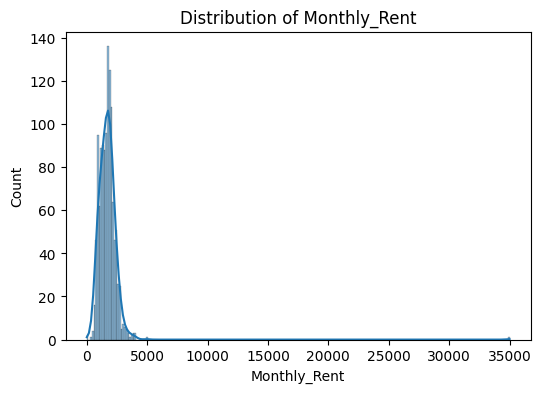

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


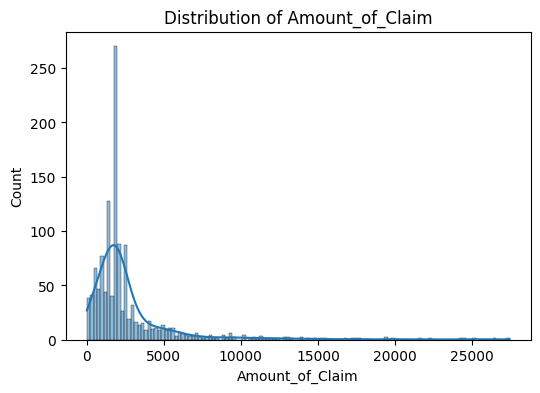

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


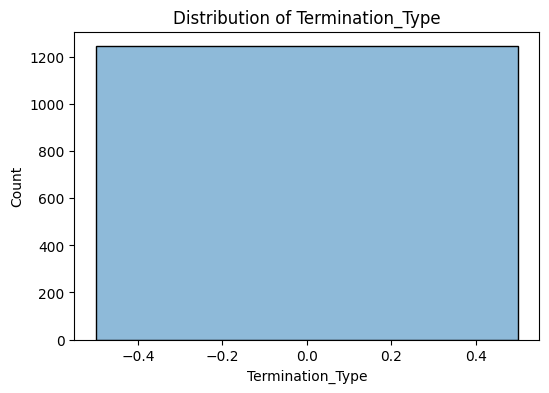

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


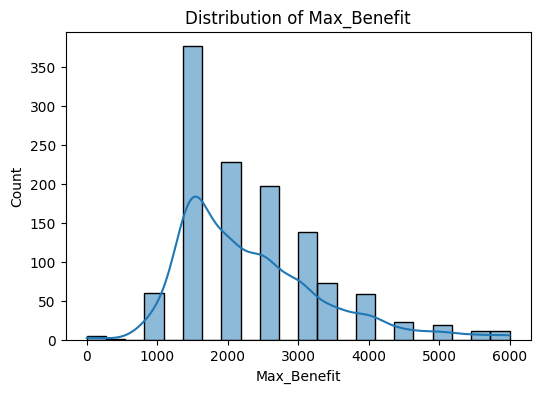

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


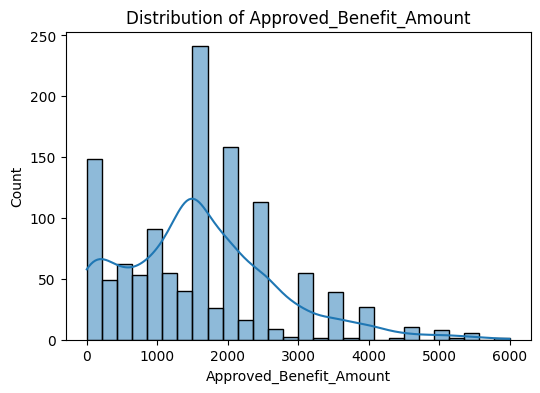

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


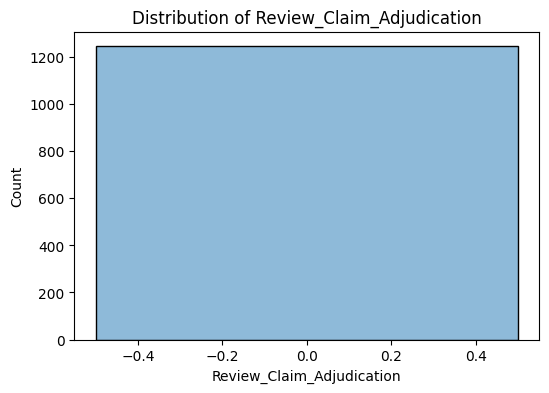

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


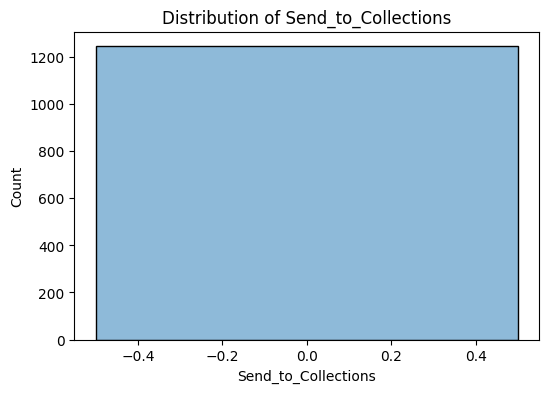

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


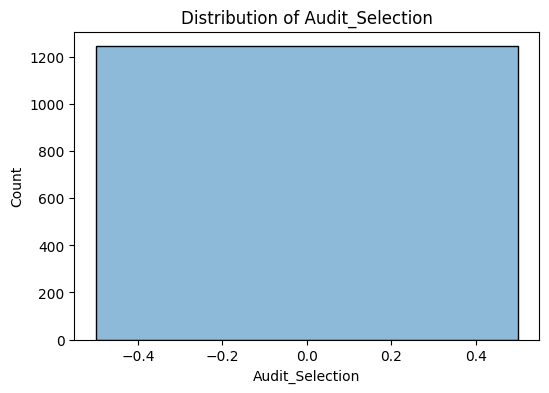

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


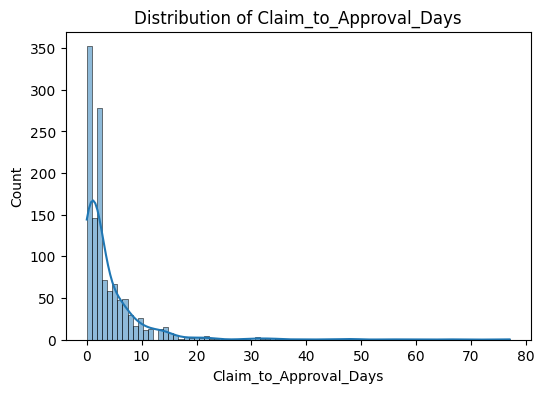

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


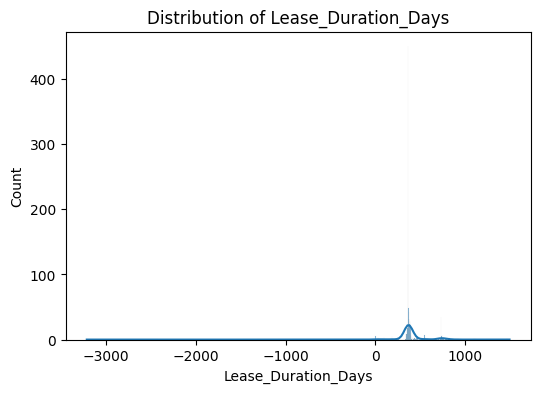

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


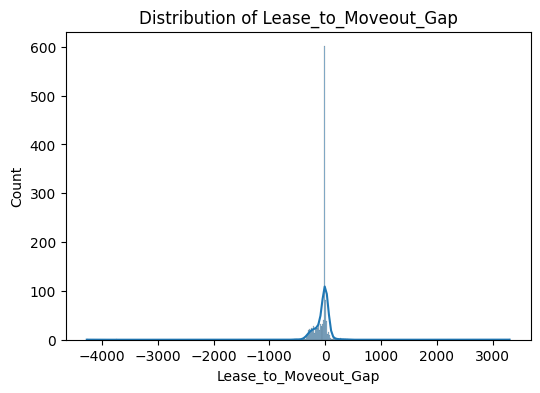

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


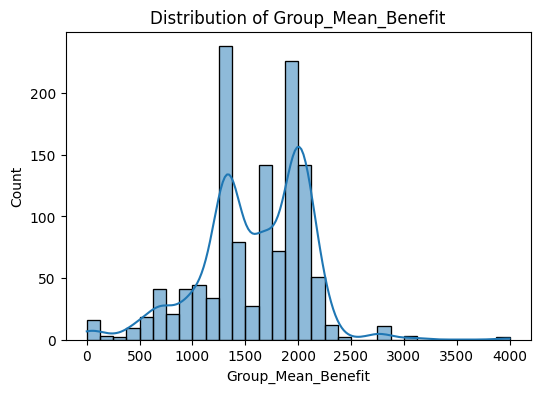

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


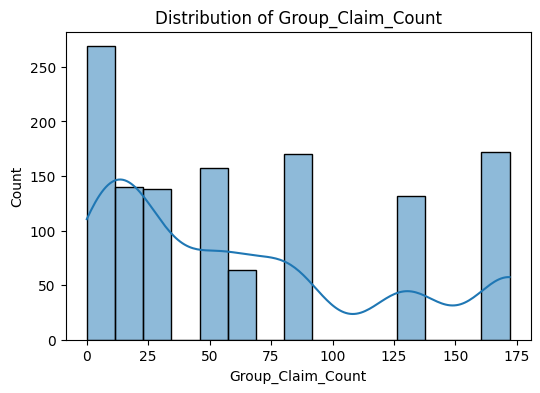

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


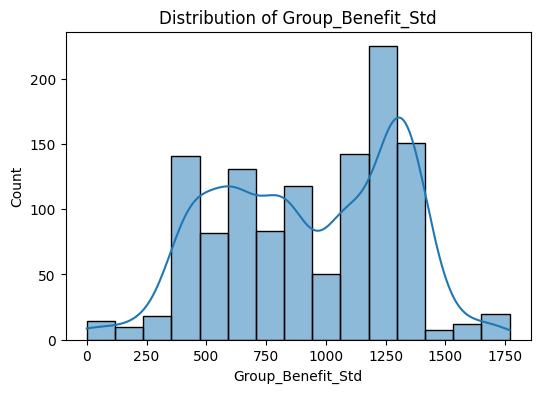

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


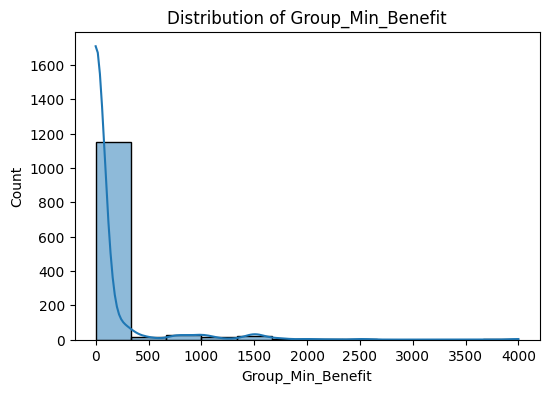

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


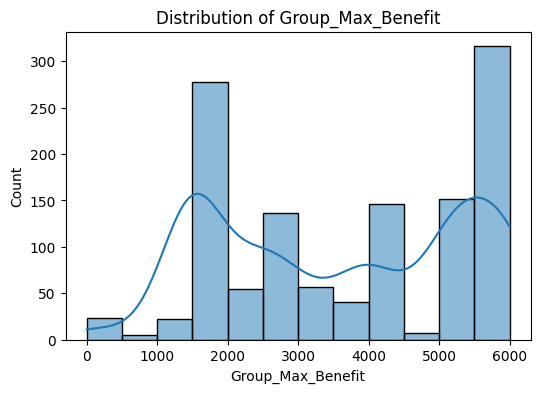

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[num_cols].describe().T

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [50]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Monthly_Rent,1207.0,1715.247225,1127.105049,1.0,1250.000000,1695.000000,2000.000000,34998.000000
Amount_of_Claim,1244.0,2613.809268,2987.546581,1.0,1311.750000,1900.000000,2500.000000,27433.000000
Termination_Type,1244.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
Max_Benefit,1198.0,2331.803005,1021.432114,0.0,1500.000000,2000.000000,3000.000000,6000.000000
Approved_Benefit_Amount,1212.0,1587.789290,1092.170089,0.0,838.272500,1500.000000,2000.000000,6000.000000
Review_Claim_Adjudication,1244.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
Send_to_Collections,1244.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
Audit_Selection,1244.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
Claim_to_Approval_Days,1244.0,3.843248,6.482753,0.0,0.000000,2.000000,5.000000,77.000000
Lease_Duration_Days,1244.0,404.975080,189.984659,-3212.0,365.000000,366.000000,379.000000,1491.000000


In [51]:
cols_to_drop = [
    'Termination_Type', 'Review_Claim_Adjudication',
    'Send_to_Collections', 'Audit_Selection',
    'Group_Min_Benefit', 'Group_Max_Benefit',
    'Lease_to_Moveout_Gap'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

df['Lease_Duration_Days'] = df['Lease_Duration_Days'].abs()

print("Dropped columns:", cols_to_drop)
print("Remaining numeric columns:", df.select_dtypes(include=['float64','int64']).columns.tolist())


Dropped columns: ['Termination_Type', 'Review_Claim_Adjudication', 'Send_to_Collections', 'Audit_Selection', 'Group_Min_Benefit', 'Group_Max_Benefit', 'Lease_to_Moveout_Gap']
Remaining numeric columns: ['Monthly_Rent', 'Amount_of_Claim', 'Max_Benefit', 'Approved_Benefit_Amount', 'Claim_to_Approval_Days', 'Lease_Duration_Days', 'Group_Mean_Benefit', 'Group_Claim_Count', 'Group_Benefit_Std']


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


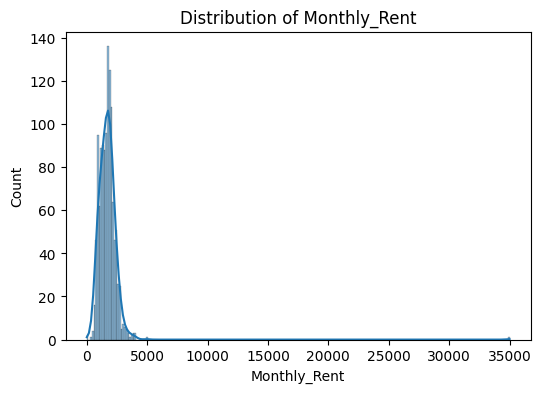

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


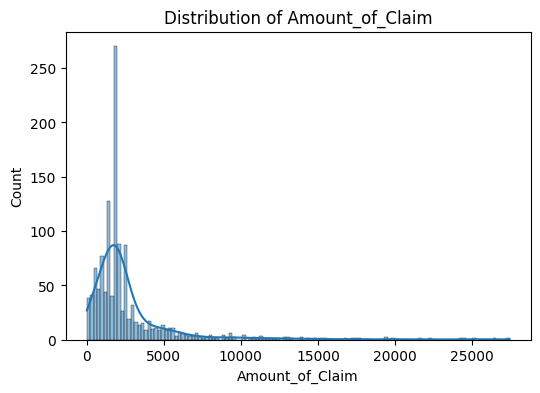

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


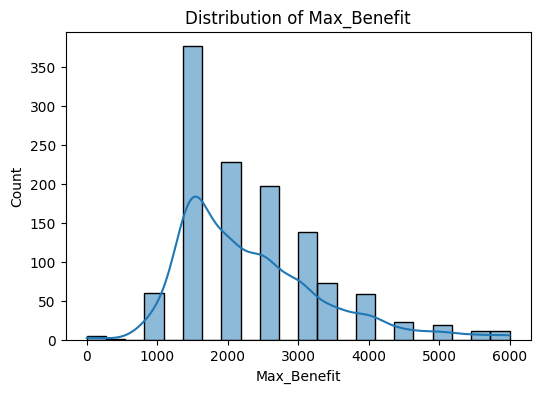

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


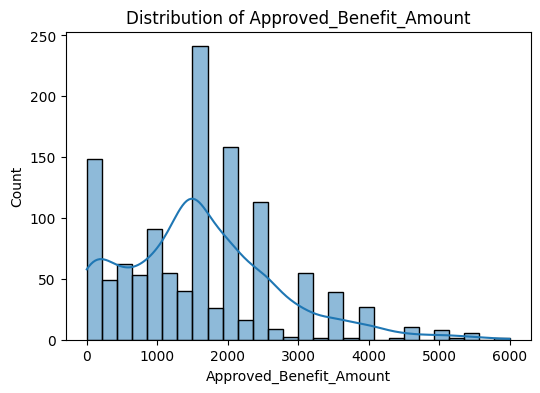

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


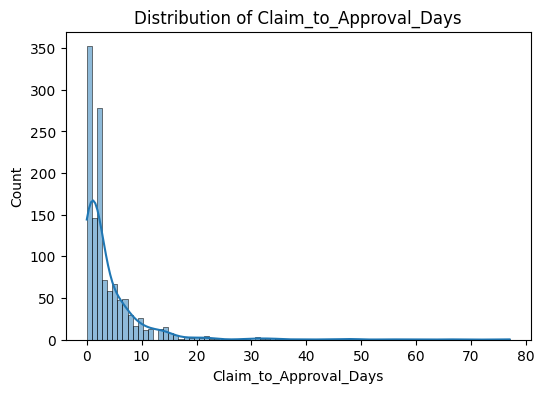

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


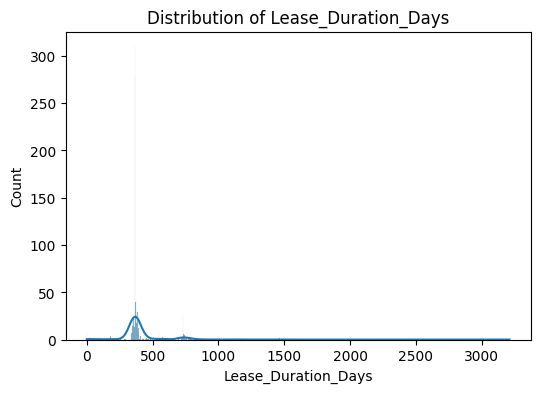

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


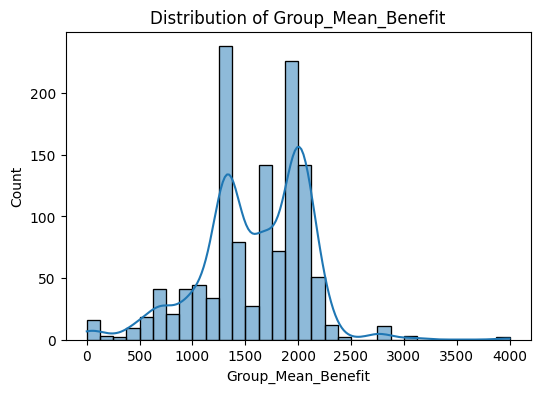

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


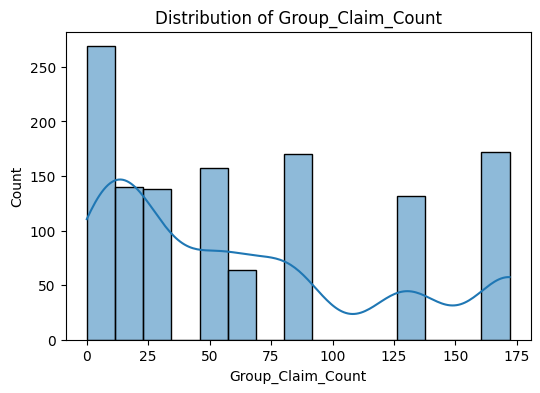

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


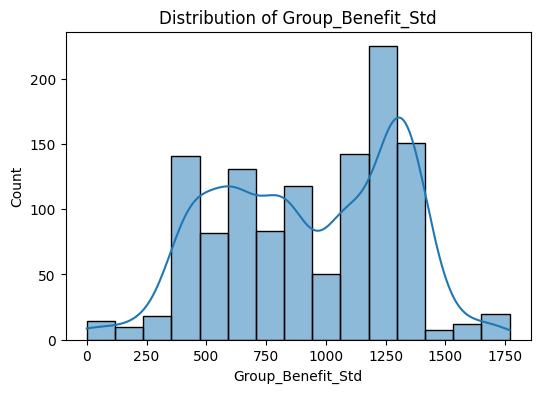

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[num_cols].describe().T

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [53]:
### Handling skewwness 
skewness = df.select_dtypes(include=['float64','int64']).skew().sort_values(ascending=False)
print(skewness)


Monthly_Rent               21.455611
Lease_Duration_Days         4.957006
Claim_to_Approval_Days      4.880176
Amount_of_Claim             4.052214
Max_Benefit                 1.156454
Approved_Benefit_Amount     0.744299
Group_Claim_Count           0.714651
Group_Benefit_Std          -0.174590
Group_Mean_Benefit         -0.415264
dtype: float64


In [55]:
df[cols_to_transform].dtypes


Monthly_Rent                float64
Collected_Amount             object
Lease_Duration_Days         float64
Claim_to_Approval_Days      float64
Amount_of_Claim             float64
Agreed_Tenant_Settlement     object
Max_Benefit                 float64
Group_Claim_Count           float64
dtype: object

In [56]:
# Clean object columns and convert to float
for col in ['Collected_Amount', 'Agreed_Tenant_Settlement']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [57]:
import numpy as np
from sklearn.preprocessing import RobustScaler

cols_to_transform = [
    'Monthly_Rent', 'Collected_Amount', 'Lease_Duration_Days',
    'Claim_to_Approval_Days', 'Amount_of_Claim',
    'Agreed_Tenant_Settlement', 'Max_Benefit', 'Group_Claim_Count'
]


for col in cols_to_transform:
    df[col] = np.log1p(np.abs(df[col]))

scaler = RobustScaler()
df[cols_to_transform] = scaler.fit_transform(df[cols_to_transform])



In [58]:
print(df[cols_to_transform].skew().sort_values(ascending=False))


Claim_to_Approval_Days       0.483272
Collected_Amount             0.000000
Agreed_Tenant_Settlement     0.000000
Group_Claim_Count           -0.663517
Amount_of_Claim             -0.752727
Lease_Duration_Days         -5.818209
Max_Benefit                 -7.076619
Monthly_Rent               -13.611932
dtype: float64


In [59]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

cols_to_fix = ['Lease_Duration_Days', 'Max_Benefit']
df[cols_to_fix] = pt.fit_transform(df[cols_to_fix])


In [60]:
print(df[cols_to_transform].skew().sort_values(ascending=False))


Claim_to_Approval_Days       0.483272
Max_Benefit                  0.002136
Collected_Amount             0.000000
Agreed_Tenant_Settlement     0.000000
Lease_Duration_Days         -0.019567
Group_Claim_Count           -0.663517
Amount_of_Claim             -0.752727
Monthly_Rent               -13.611932
dtype: float64


In [61]:
### changing the dataset 
for col in cols_to_transform:
    df[col] = np.log1p(np.abs(df[col]))


In [62]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df[cols_to_fix] = pt.fit_transform(df[cols_to_fix])

In [63]:
df[cols_to_transform].skew()


Monthly_Rent                1.816056
Collected_Amount            0.000000
Lease_Duration_Days         0.387524
Claim_to_Approval_Days      0.005856
Amount_of_Claim             0.671273
Agreed_Tenant_Settlement    0.000000
Max_Benefit                 0.060420
Group_Claim_Count           0.388330
dtype: float64

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


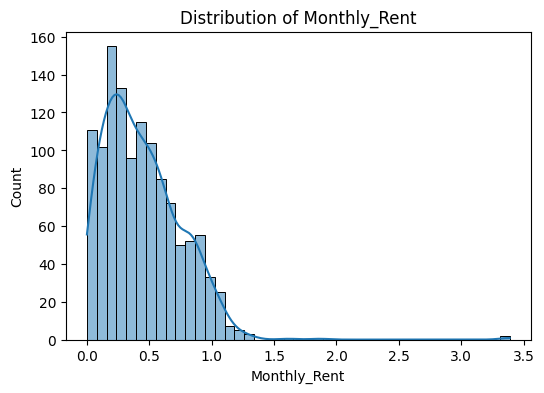

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


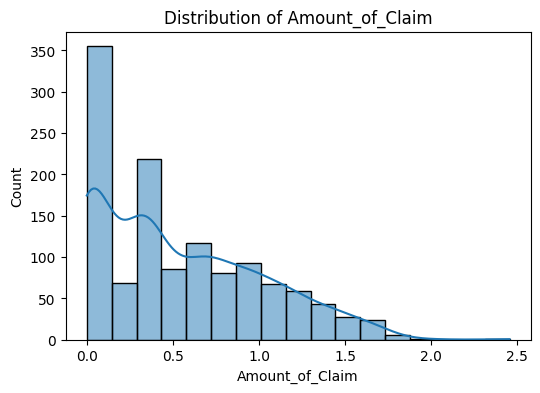

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


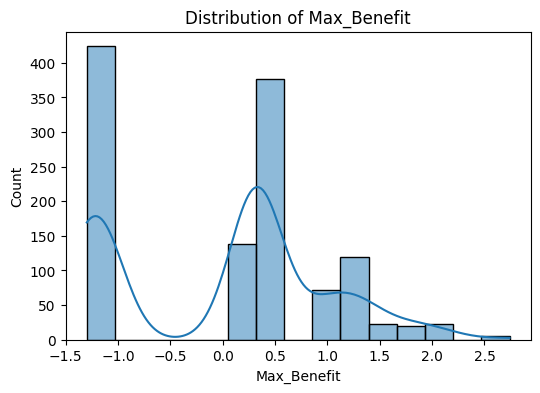

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


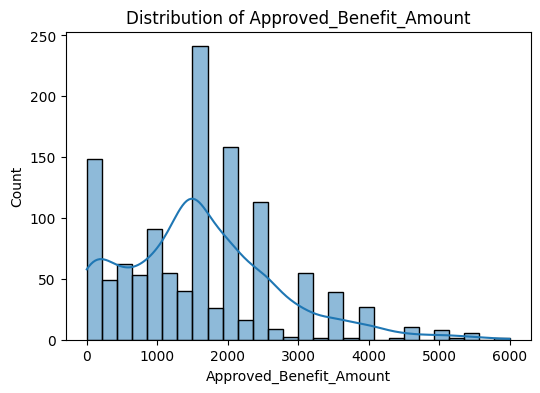

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


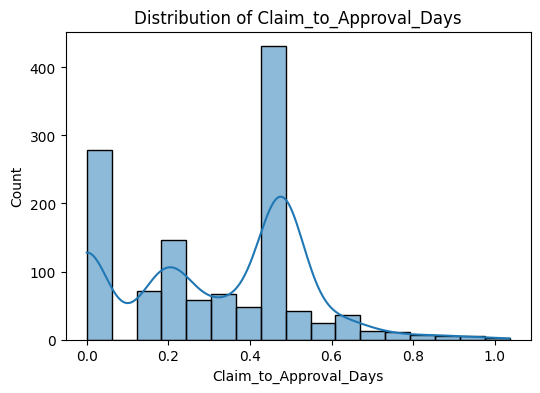

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


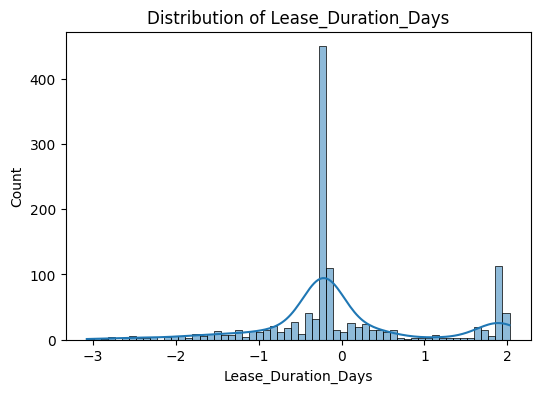

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


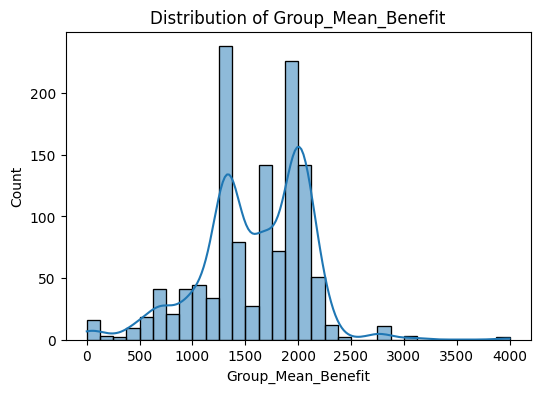

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


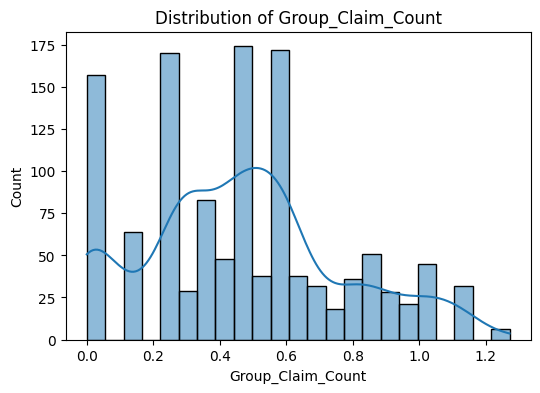

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


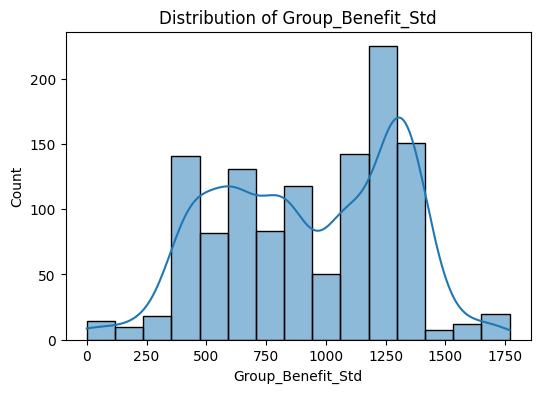

In [65]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

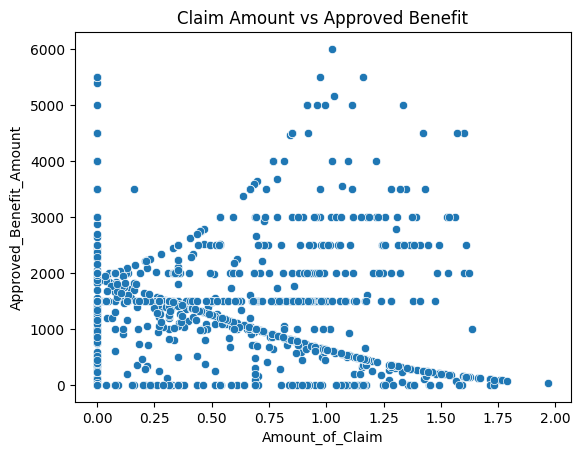

In [66]:
sns.scatterplot(x='Amount_of_Claim', y='Approved_Benefit_Amount', data=df)
plt.title('Claim Amount vs Approved Benefit')
plt.show()


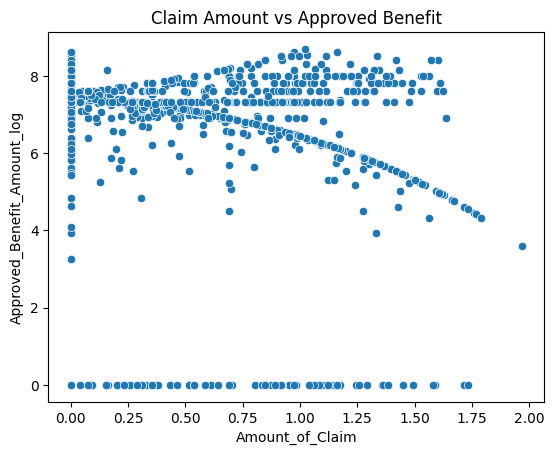

In [73]:
sns.scatterplot(x='Amount_of_Claim', y='Approved_Benefit_Amount_log', data=df)
plt.title('Claim Amount vs Approved Benefit')
plt.show()


In [74]:
df = df.drop(columns=['Approved_Benefit_Amount'], errors='ignore')


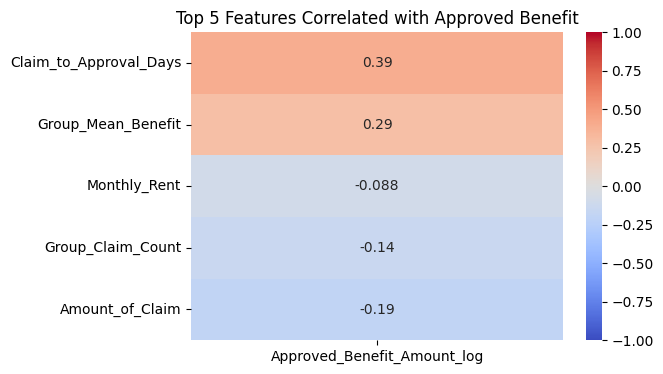

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlations for numeric columns
corr = df.select_dtypes(include=['float64', 'int64']).corr()

# Get top 5 correlated features (excluding the target itself)
top_corr = (
    corr['Approved_Benefit_Amount_log']
    .drop('Approved_Benefit_Amount_log')        # remove self-correlation
    .abs()                                     # use absolute correlation
    .sort_values(ascending=False)
    .head(5)                                   # top 5 features
    .index
)

# Filter correlation matrix for only those top features
top_corr_matrix = corr.loc[top_corr, ['Approved_Benefit_Amount_log']]

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(top_corr_matrix.sort_values(by='Approved_Benefit_Amount_log', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Top 5 Features Correlated with Approved Benefit')
plt.show()




In [80]:
### Some Miscallenious 
bool_map = {'yes': 1, 'true': 1, 'no': 0, 'false': 0}

for col in ['Is_there_a_2nd_Tenant?', 'Is_there_a_3rd_Tenant?',
            'Review_Tenant_Information', 'Update_YRIG_Policy_Info',
            'Open_Collections', 'View_PM_Information']:
    df[col] = df[col].astype(str).str.lower().map(bool_map).fillna(0)


In [81]:
cat_cols = ['Tenant_Contacted', 'Tenant_Collection_Status', 'Collection_Status']

for col in cat_cols:
    df[col] = df[col].astype('category')


In [82]:
for col in ['Agreed_Tenant_Settlement', 'Collected_Amount']:
    df[col] = (df[col]
               .astype(str)
               .str.replace('[\$,]', '', regex=True)
               .str.extract('(\d+\.?\d*)')[0]   # extract numeric part only
               .astype(float))


In [90]:
import numpy as np

mask = (
    df['Approved_Benefit_Amount_log'].isna() |
    ~np.isfinite(df['Approved_Benefit_Amount_log'])
)

print("Invalid target rows:", mask.sum())
print(df.loc[mask, ['Approved_Benefit_Amount_log']].head(10))


Invalid target rows: 0
Empty DataFrame
Columns: [Approved_Benefit_Amount_log]
Index: []


In [91]:
df = df.dropna(subset=['Approved_Benefit_Amount_log']).reset_index(drop=True)
print("Remaining rows after cleanup:", len(df))


Remaining rows after cleanup: 1212


In [92]:
import numpy as np
print(df['Approved_Benefit_Amount_log'].isna().sum())     
print(np.isfinite(df['Approved_Benefit_Amount_log']).all())  


0
True


### MODEL TRAINING

In [99]:
# --- Step 1: Fix any lingering object columns ---
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

# --- Step 2: Ensure categorical columns are truly category dtype ---
for col in df.select_dtypes(include='category').columns:
    # Convert any string 'nan' or 'none' to proper NaN
    df[col] = df[col].replace(['nan', 'none', 'NaN', 'None'], np.nan).astype('category')

# --- Step 3: Confirm all columns are valid types ---
print(df.dtypes.value_counts())
print("\nInvalid dtypes ")
print(df.select_dtypes(exclude=['number', 'bool', 'category']).columns)


float64     17
category     1
category     1
category     1
category     1
Name: count, dtype: int64

Invalid dtypes (should be empty):
Index([], dtype='object')


In [100]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

X = df.drop('Approved_Benefit_Amount_log', axis=1)
y = df['Approved_Benefit_Amount_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")


MSE: 0.80
RMSE: 0.89


In [101]:
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

print(f"SMAPE: {smape(y_test, y_pred):.2f}%")


SMAPE: 22.00%


### Model training 2

In [103]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

X = df.drop('Approved_Benefit_Amount_log', axis=1)
y = df['Approved_Benefit_Amount_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    enable_categorical=True,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")


MSE: 0.80
RMSE: 0.89


In [104]:
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

print(f"SMAPE: {smape(y_test, y_pred):.2f}%")


SMAPE: 22.00%





## Dealing with Image data 

In [107]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd


In [109]:
pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 2.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 4.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.0 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.5.2
    Uninstalling widgetsnbextension-3.5.2:
      Successfully uninstalled widgetsnbextension-3.5.2
  Attempting uninstall: jupyterlab_widgets
    Found existing installation: jupyterlab-widgets 3.0.9
    Uninstalling jupyterlab-widgets-3.0.9:
      Successfully uninstalled jupyterlab-widgets-3.0.9
  Attempting uninstall: comm
    Found existing installation: comm 0.1.2
    Uninstalling comm-0.1.2:
      Successfully uninstalled comm-0.1.2
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.6.5
    Uninstalling ipywidgets-7.6.5:
      Successfully uninstalled ipywidgets-7.6.5
Note: you may need to restart

In [111]:
jupyter labextension develop --overwrit


SyntaxError: invalid syntax (1199306730.py, line 1)

In [114]:
df.select_dtypes(exclude=['number']).columns.tolist()


['Tenant_Contacted', 'Tenant_Collection_Status', 'Collection_Status', 'Status']

In [133]:
### working
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine both columns for richer text
text_df['Combined_Text'] = text_df['PM_Explanation'] + ' ' + text_df['Hold_Reason']

# Apply TF-IDF
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(text_df['Combined_Text'])

# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f'TFIDF_{w}' for w in tfidf.get_feature_names_out()])

# Merge back with main df
df = pd.concat([df.reset_index(drop=True), tfidf_df], axis=1)


In [132]:
print(df['Approved_Benefit_Amount_log'].isna().sum())


0
